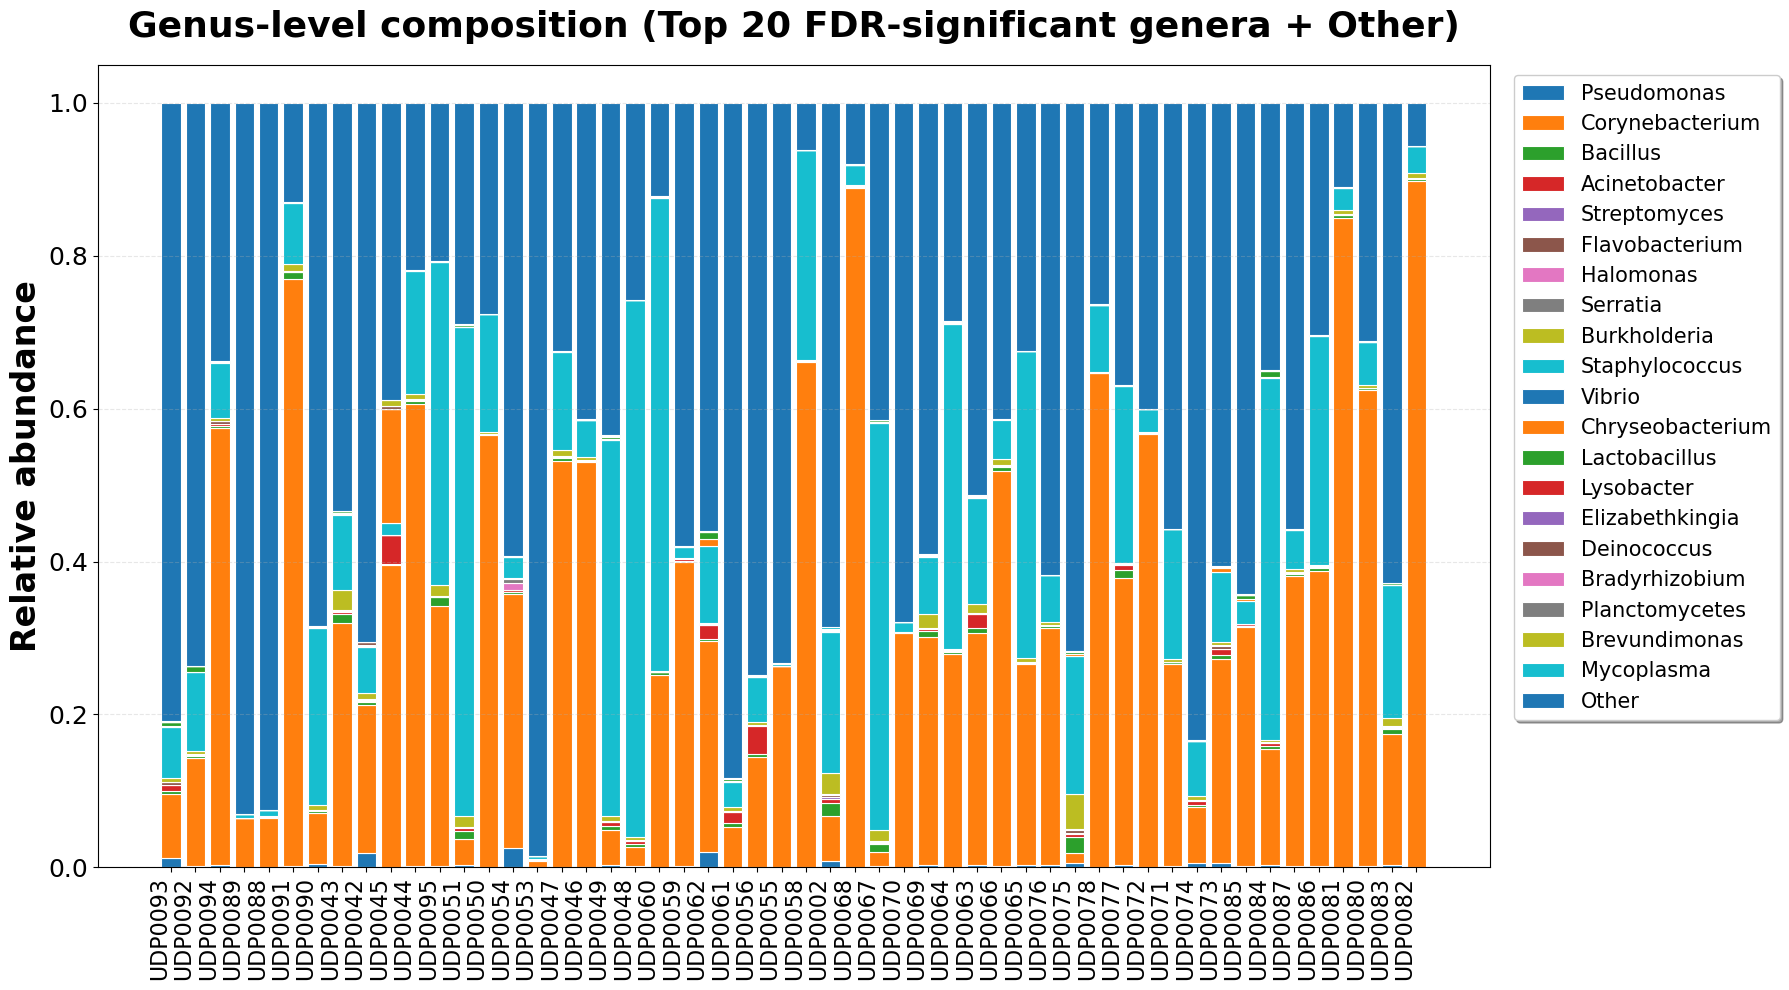

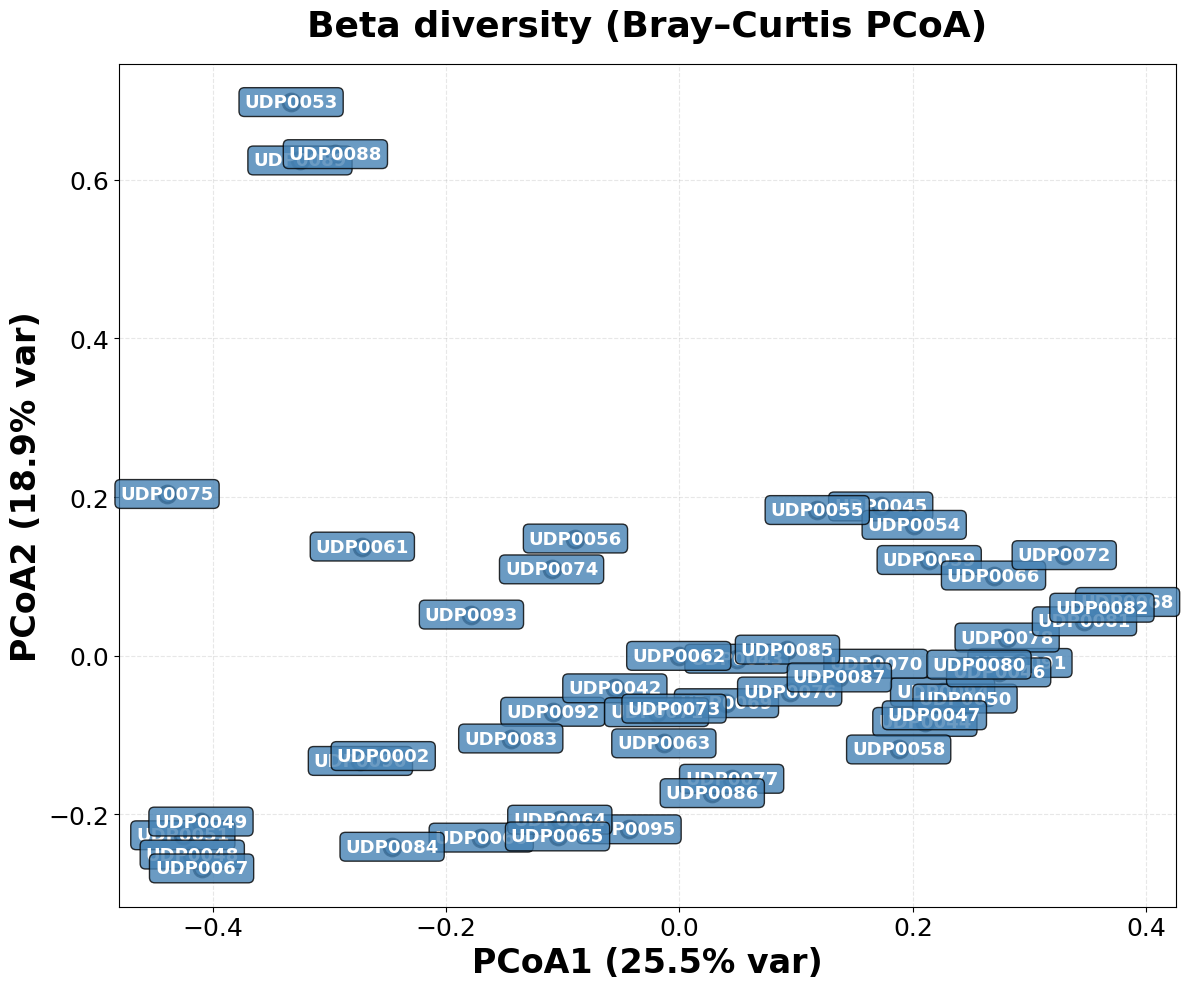

In [25]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

os.makedirs('../results', exist_ok=True)

def clean_sample_name(x):
    if not isinstance(x, str):
        return str(x)
    m = re.search(r'UDP\d{3,5}', x, flags=re.IGNORECASE)
    if m:
        return m.group(0).upper()
    m = re.search(r'\b\d{5}-\d{3}\b', x)
    if m:
        return m.group(0)
    return x

def infer_genus(s):
    if not isinstance(s, str):
        return 'Unassigned'
    t = s.strip().replace('_', ' ').split()
    if not t:
        return 'Unassigned'
    if t[0].lower() == 'candidatus' and len(t) >= 2:
        return t[1]
    return t[0].strip('[]();,') or 'Unassigned'

def relative_abundance(df):
    colsum = df.sum(axis=0)
    colsum = colsum.replace(0, 1.0)
    return df / colsum

def classical_mds(D, n_components=2):
    D = np.asarray(D, dtype=float)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D**2) @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos = eigvals > 0
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]
    if eigvals.size == 0:
        return np.zeros((n, n_components)), np.array([])
    L = np.sqrt(eigvals[:n_components])
    V = eigvecs[:, :n_components]
    return V * L, eigvals

with open('../data/pTau versus bacteria FDR 0.05.txt', 'r', encoding='utf-8', errors='ignore') as f:
    fdr_taxa = [ln.strip() for ln in f if ln.strip()]

try:
    raw = pd.read_csv('../data/Metagenomics_NextGen_Feature_on_Rows.txt', sep='\t')
except Exception:
    raw = pd.read_csv('../data/Metagenomics_NextGen_Feature_on_Rows.txt')

raw = raw.dropna(subset=[raw.columns[0]])
raw = raw.rename(columns={raw.columns[0]: 'feature'})
raw.index = raw['feature'].astype(str)
abund = raw.drop(columns=['feature']).apply(pd.to_numeric, errors='coerce').fillna(0.0)

orig_cols = list(abund.columns)
clean_cols = [clean_sample_name(c) for c in orig_cols]
pd.DataFrame({'original': orig_cols, 'cleaned': clean_cols}).to_csv('../results/sample_name_mapping.csv', index=False)
abund.columns = clean_cols

genus_map = pd.Series({feat: infer_genus(feat) for feat in abund.index})
genus_abund = abund.groupby(genus_map).sum()
genus_rel = relative_abundance(genus_abund)

fdr_genera = [infer_genus(t) for t in fdr_taxa]
fdr_genus_counts = pd.Series(fdr_genera).value_counts()
fdr_genus_counts.to_csv('../results/significant_genus_counts_top20.csv', header=['count'])

top20 = list(fdr_genus_counts.head(20).index)
present_top20 = [g for g in top20 if g in genus_rel.index]
stack_mat = genus_rel.loc[present_top20].copy()
stack_mat.loc['Other'] = (1.0 - stack_mat.sum(axis=0)).clip(lower=0)

plt.figure(figsize=(18, 10))
bottom = np.zeros(stack_mat.shape[1])
x = np.arange(stack_mat.shape[1])
for genus in stack_mat.index:
    vals = stack_mat.loc[genus].values
    plt.bar(x, vals, bottom=bottom, label=genus, edgecolor='white', linewidth=0.8)
    bottom += vals
plt.xticks(x, stack_mat.columns, rotation=90, fontsize=16, ha='right')
plt.yticks(fontsize=18)
plt.ylabel('Relative abundance', fontsize=24, fontweight='bold')
plt.title('Genus-level composition (Top 20 FDR-significant genera + Other)', 
          fontsize=26, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1, fontsize=15, 
          frameon=True, shadow=True, fancybox=True)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../results/big_font_top20_genera_stacked2.pdf', dpi=300, bbox_inches='tight')
plt.show()

genus_rel.loc[present_top20].T.to_csv('../results/top20_genus_relative_abundance_by_sample.csv')

X = genus_rel.T.values
bray = squareform(pdist(X, metric='braycurtis'))
coords, eigvals = classical_mds(bray, n_components=2)
explained = (eigvals / eigvals.sum()) if eigvals.size and eigvals.sum() > 0 else np.array([0, 0])

plt.figure(figsize=(12, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=150, alpha=0.75, edgecolors='black', 
           linewidth=2, c='steelblue', zorder=3)
if genus_rel.shape[1] <= 60:
    for i, sid in enumerate(genus_rel.columns):
        plt.text(coords[i, 0], coords[i, 1], str(sid), fontsize=13, ha='center', 
                va='center', fontweight='bold', color='white', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='steelblue', edgecolor='black', alpha=0.8))
plt.xlabel(f'PCoA1 ({explained[0]*100:.1f}% var)' if explained.size > 0 else 'PCoA1', 
          fontsize=24, fontweight='bold')
plt.ylabel(f'PCoA2 ({explained[1]*100:.1f}% var)' if explained.size > 1 else 'PCoA2', 
          fontsize=24, fontweight='bold')
plt.title('Beta diversity (Bray–Curtis PCoA)', fontsize=26, fontweight='bold', pad=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=1)
plt.tight_layout()
plt.savefig('../results/big_font_beta_diversity_pcoa2.pdf', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame(coords[:, :2], columns=['PCoA1', 'PCoA2'], index=genus_rel.columns).to_csv('../results/beta_diversity_pcoa_coords.csv')

Creating phylum-level abundance table...
Phyla detected in the dataset:
  Other/Unassigned: 0.4304 (average relative abundance)
  Actinobacteria: 0.3299 (average relative abundance)
  Firmicutes: 0.1904 (average relative abundance)
  Proteobacteria: 0.0328 (average relative abundance)
  Bacteroidetes: 0.0115 (average relative abundance)
  Fusobacteria: 0.0035 (average relative abundance)
  Spirochaetes: 0.0007 (average relative abundance)
  Deinococcus-Thermus: 0.0003 (average relative abundance)
  Tenericutes: 0.0001 (average relative abundance)
  Verrucomicrobia: 0.0001 (average relative abundance)
  Acidobacteria: 0.0001 (average relative abundance)
  Planctomycetes: 0.0000 (average relative abundance)
  Cyanobacteria: 0.0000 (average relative abundance)
  Archaea: 0.0000 (average relative abundance)
  Chloroflexi: 0.0000 (average relative abundance)
  Nitrospirae: 0.0000 (average relative abundance)

Creating phyla-level stacked bar chart...


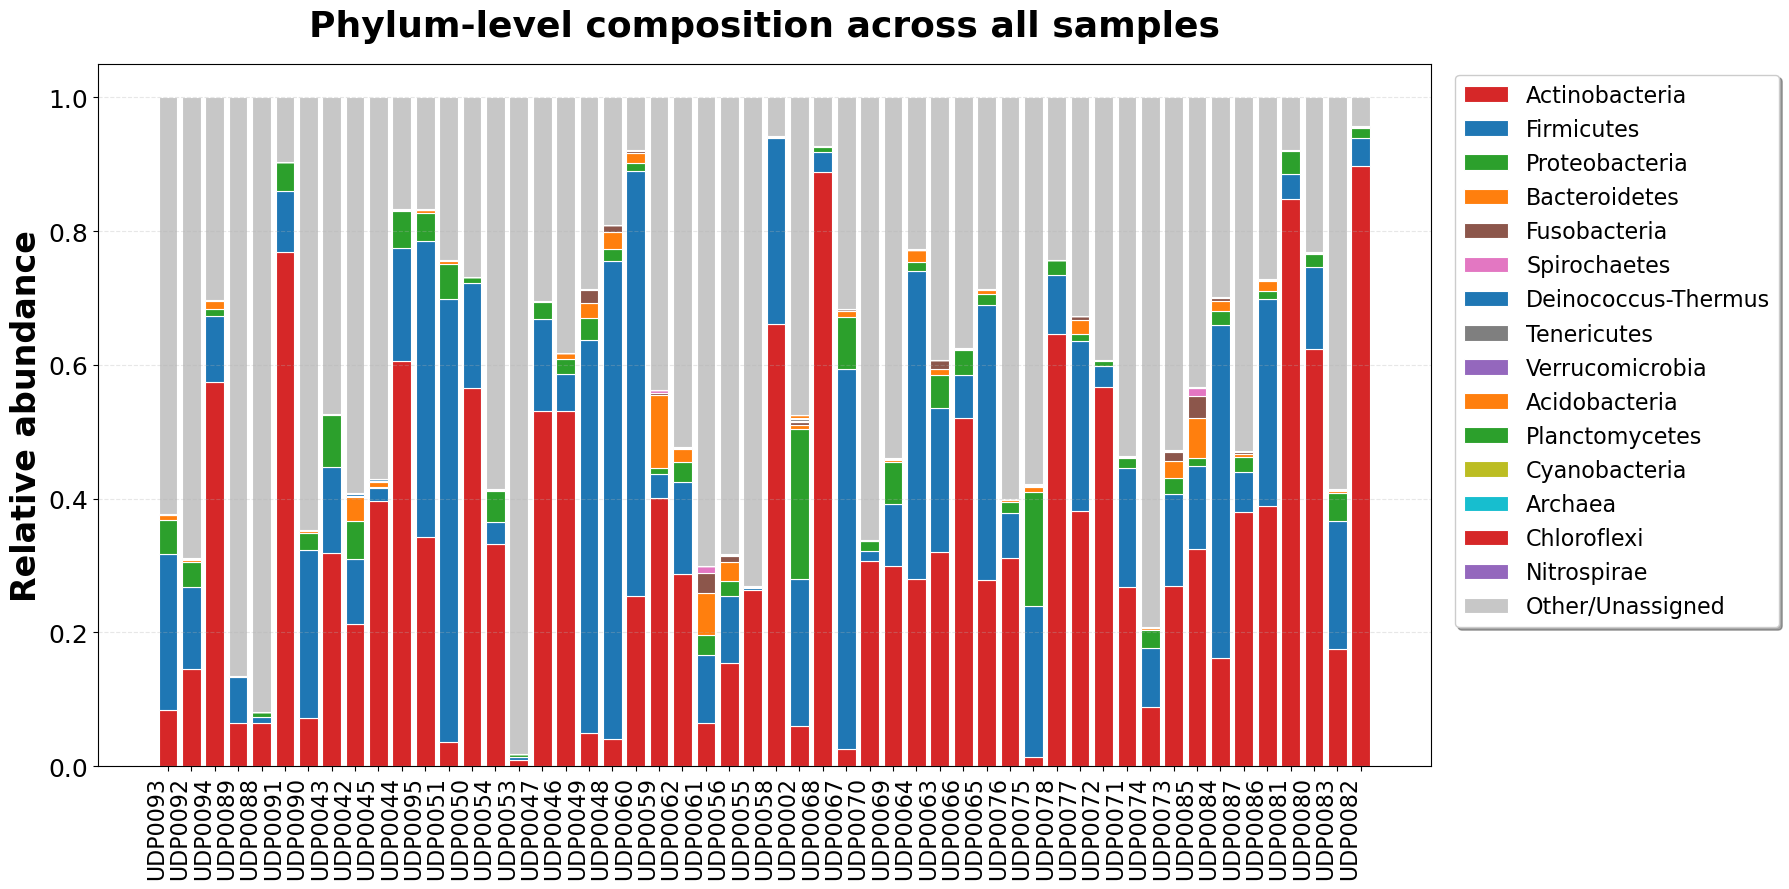


Saved files:
  - ../results/big_font_phyla_level_stacked.pdf
  - ../results/phylum_relative_abundance_by_sample.csv
  - ../results/phylum_average_abundances.csv


In [26]:
# ---------- PHYLA-LEVEL ANALYSIS ----------

def infer_phylum(feature_name):
    """
    Extract phylum from taxonomic feature names.
    Many bacterial names follow patterns that can help infer phylum.
    """
    if not isinstance(feature_name, str):
        return 'Unassigned'
    
    name = feature_name.lower().strip()
    
    # Common bacterial phyla patterns
    if any(x in name for x in ['firmicutes', 'clostrid', 'bacill', 'lactobacill', 'streptococ', 'enterococ', 'staphylococ']):
        return 'Firmicutes'
    elif any(x in name for x in ['bacteroid', 'prevotella', 'porphyromon', 'flavobacter']):
        return 'Bacteroidetes'
    elif any(x in name for x in ['proteobacter', 'escherichia', 'salmonella', 'pseudomon', 'helicobacter', 'campylobacter', 'vibrio', 'shigella', 'klebsiella', 'enterobacter', 'citrobacter', 'serratia', 'proteus']):
        return 'Proteobacteria'
    elif any(x in name for x in ['actinobacter', 'bifidobacter', 'corynebacter', 'mycobacter', 'propionibacter', 'actinomyc']):
        return 'Actinobacteria'
    elif any(x in name for x in ['verrucomicr', 'akkermansia']):
        return 'Verrucomicrobia'
    elif any(x in name for x in ['fusobacter']):
        return 'Fusobacteria'
    elif any(x in name for x in ['spirochaet', 'treponema']):
        return 'Spirochaetes'
    elif any(x in name for x in ['tenericutes', 'mycoplasma']):
        return 'Tenericutes'
    elif any(x in name for x in ['cyanobacter']):
        return 'Cyanobacteria'
    elif any(x in name for x in ['deinococcus', 'thermus']):
        return 'Deinococcus-Thermus'
    elif any(x in name for x in ['planctomyc']):
        return 'Planctomycetes'
    elif any(x in name for x in ['chloroflex']):
        return 'Chloroflexi'
    elif any(x in name for x in ['acidobacter']):
        return 'Acidobacteria'
    elif any(x in name for x in ['nitrosopir', 'nitrosomonas']):
        return 'Nitrospirae'
    elif 'archaea' in name or any(x in name for x in ['methanobrev', 'methanosph', 'halobacter']):
        return 'Archaea'
    else:
        return 'Other/Unassigned'

# Create phylum-level abundance table
print("Creating phylum-level abundance table...")
phylum_map = pd.Series({feat: infer_phylum(feat) for feat in abund.index})
phylum_abund = abund.groupby(phylum_map).sum()
phylum_rel = relative_abundance(phylum_abund)

# Display phylum composition
print("Phyla detected in the dataset:")
phylum_total_abundance = phylum_rel.mean(axis=1).sort_values(ascending=False)
for phylum, abundance in phylum_total_abundance.items():
    print(f"  {phylum}: {abundance:.4f} (average relative abundance)")

# Create stacked bar chart for phyla
print("\nCreating phyla-level stacked bar chart...")

# Sort phyla by average abundance (excluding Other/Unassigned for now)
phyla_order = phylum_total_abundance.index.tolist()
if 'Other/Unassigned' in phyla_order:
    phyla_order.remove('Other/Unassigned')
    phyla_order.append('Other/Unassigned')  # Put at the end

# Reorder the matrix
phylum_stack_mat = phylum_rel.loc[phyla_order]

# Create the plot
plt.figure(figsize=(18, 9))
bottom = np.zeros(phylum_stack_mat.shape[1])
x = np.arange(phylum_stack_mat.shape[1])

# Define colors for major phyla
phylum_colors = {
    'Firmicutes': '#1f77b4',
    'Bacteroidetes': '#ff7f0e', 
    'Proteobacteria': '#2ca02c',
    'Actinobacteria': '#d62728',
    'Verrucomicrobia': '#9467bd',
    'Fusobacteria': '#8c564b',
    'Spirochaetes': '#e377c2',
    'Tenericutes': '#7f7f7f',
    'Cyanobacteria': '#bcbd22',
    'Archaea': '#17becf',
    'Other/Unassigned': '#c7c7c7'
}

for phylum in phylum_stack_mat.index:
    vals = phylum_stack_mat.loc[phylum].values
    color = phylum_colors.get(phylum, None)
    plt.bar(x, vals, bottom=bottom, label=phylum, color=color, edgecolor='white', linewidth=0.8)
    bottom += vals

plt.xticks(x, phylum_stack_mat.columns, rotation=90, fontsize=16, ha='right')
plt.yticks(fontsize=18)
plt.ylabel('Relative abundance', fontsize=24, fontweight='bold')
plt.title('Phylum-level composition across all samples', fontsize=26, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", ncol=1, fontsize=16, 
          frameon=True, shadow=True, fancybox=True)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../results/big_font_phyla_level_stacked.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Save phylum-level data
phylum_rel.T.to_csv('../results/phylum_relative_abundance_by_sample.csv')
phylum_total_abundance.to_csv('../results/phylum_average_abundances.csv', header=['average_abundance'])

print(f"\nSaved files:")
print(f"  - ../results/big_font_phyla_level_stacked.pdf")
print(f"  - ../results/phylum_relative_abundance_by_sample.csv")
print(f"  - ../results/phylum_average_abundances.csv")

Calculating alpha diversity metrics...

Alpha diversity summary:
       Observed_Richness    Shannon    Simpson  Pielou_Evenness
count          52.000000  52.000000  52.000000        52.000000
mean          535.480769   1.951772   0.680028         0.309635
std           100.776493   0.738311   0.203564         0.112871
min           260.000000   0.383954   0.150165         0.065937
25%           491.000000   1.513780   0.596888         0.245169
50%           553.500000   1.978838   0.734679         0.318497
75%           601.250000   2.370543   0.827613         0.371169
max           694.000000   3.396086   0.926141         0.532860


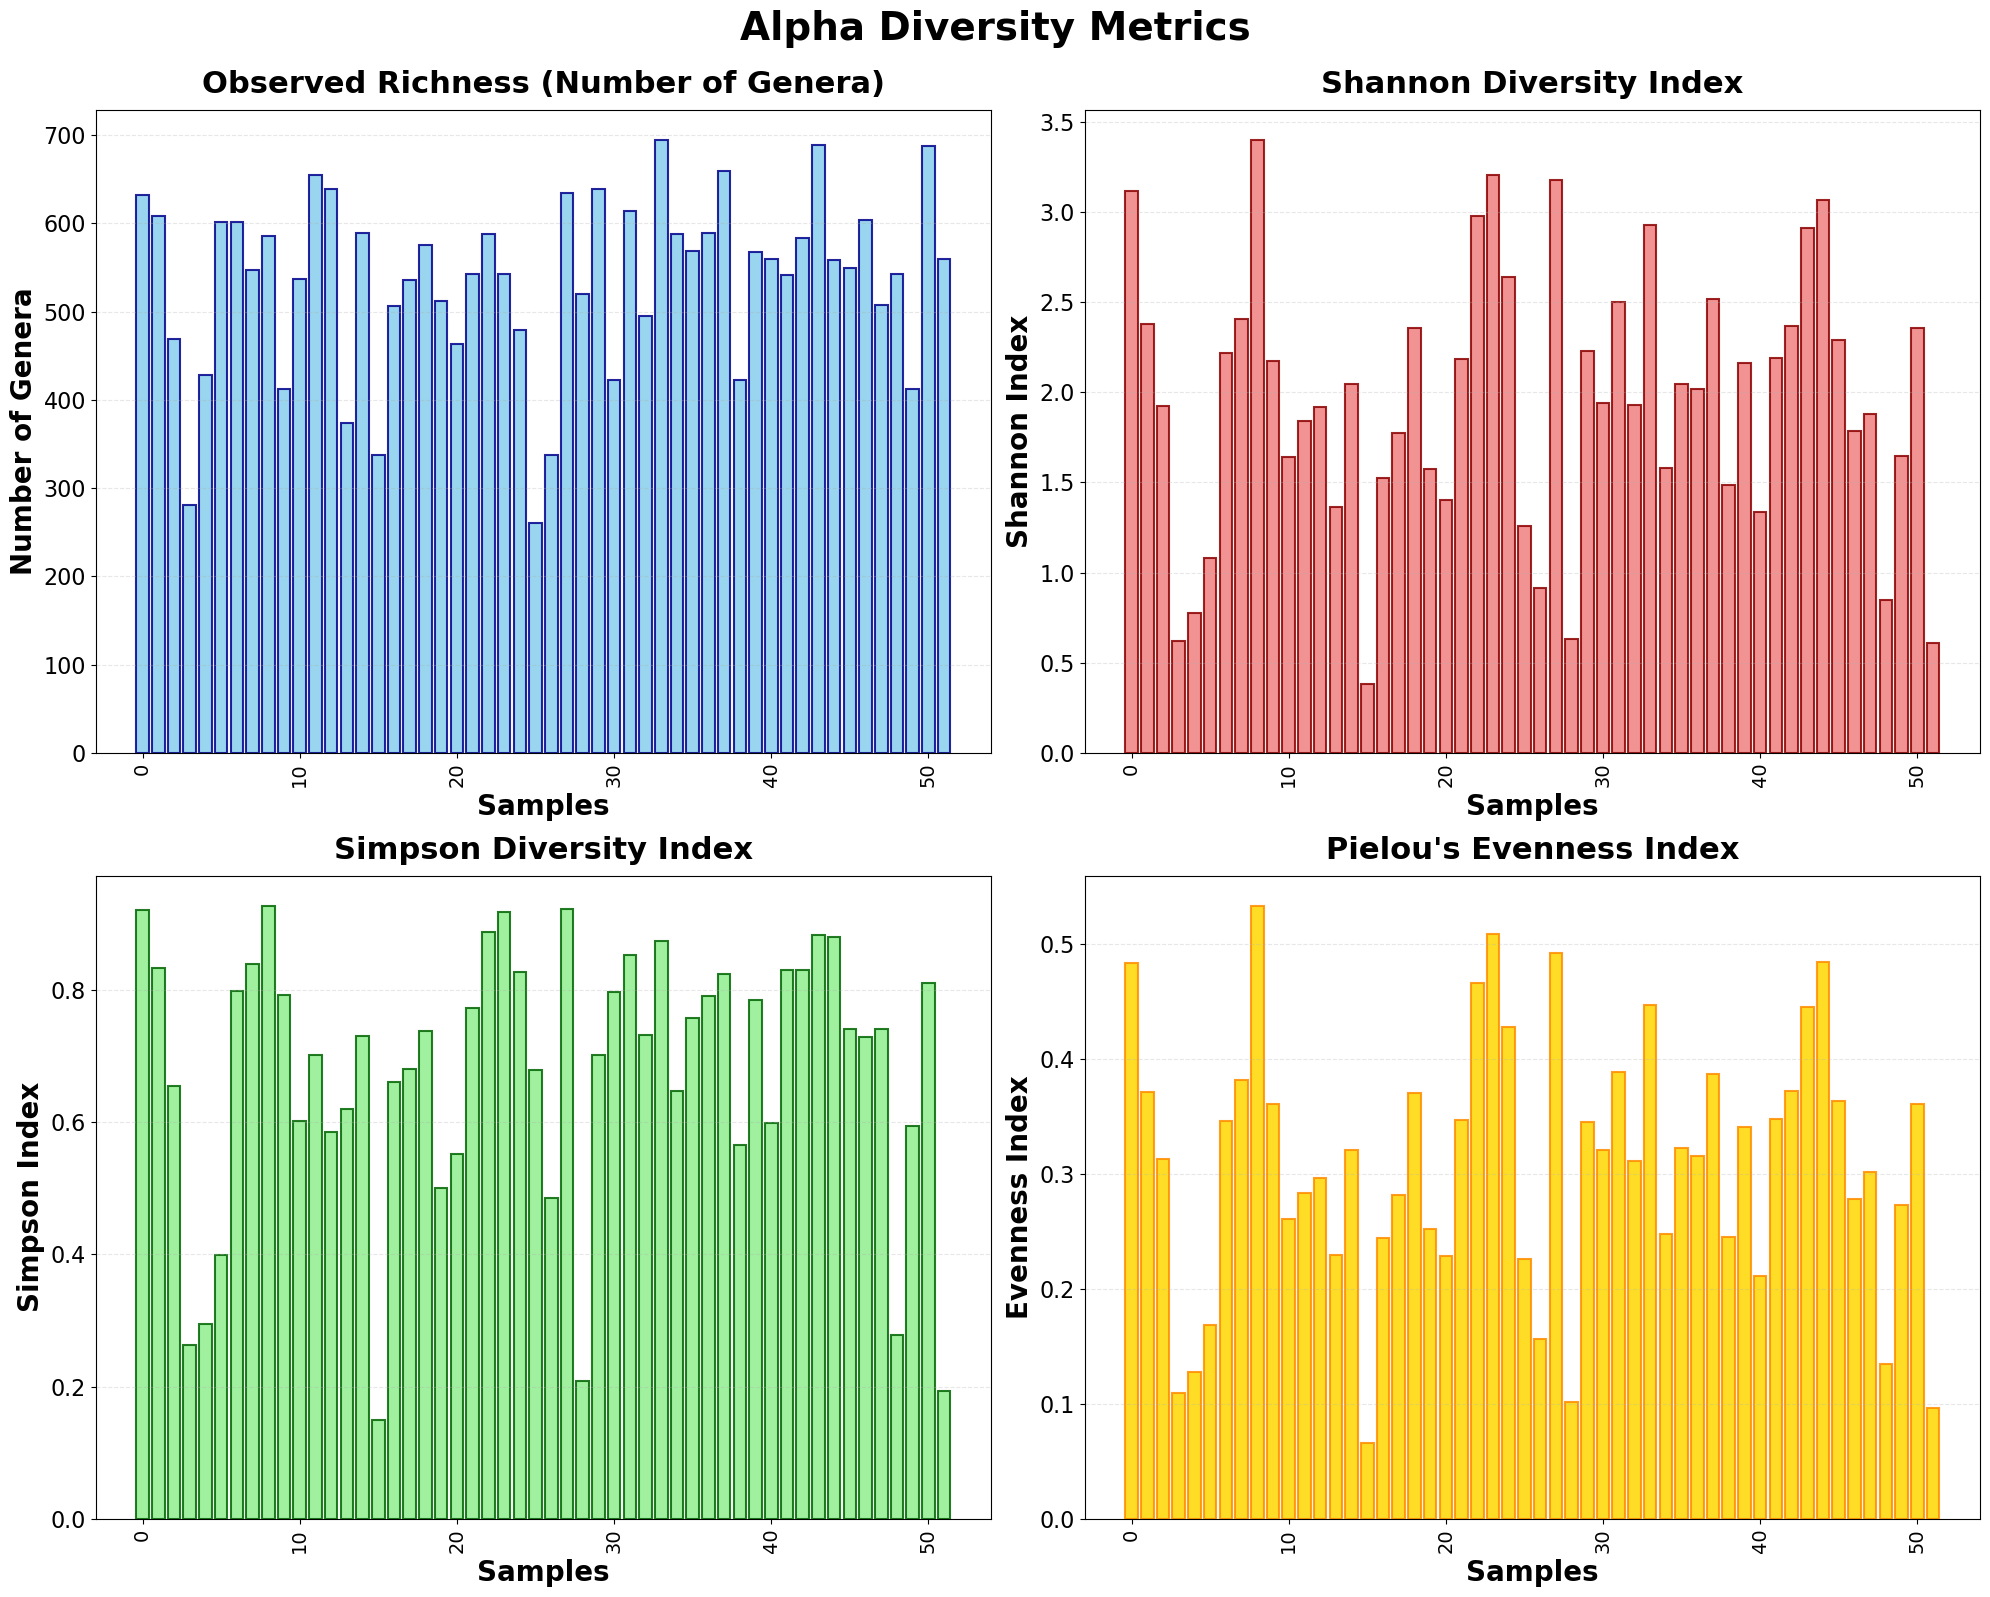

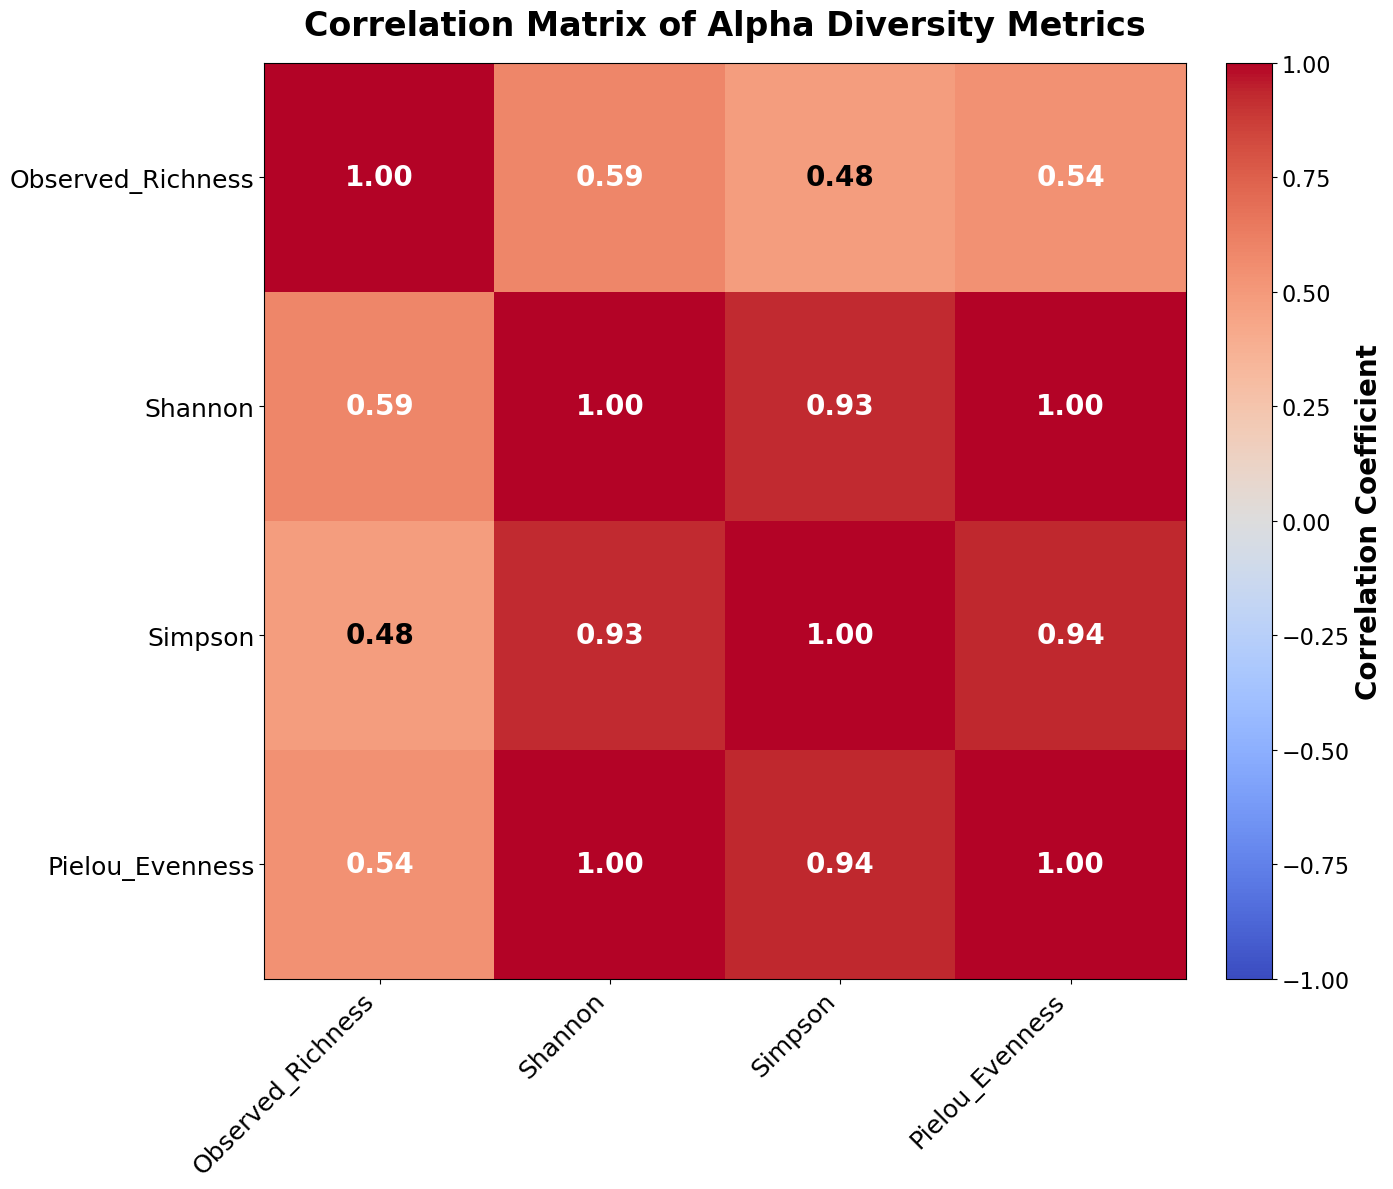


Saved files:
  - ../results/alpha_diversity_metrics.csv
  - ../results/big_font_alpha_diversity_plots.pdf
  - ../results/big_font_alpha_diversity_correlation.pdf

Samples with highest and lowest diversity:

Observed_Richness:
  Highest: UDP0063 (694.000)
  Lowest:  UDP0055 (260.000)

Shannon:
  Highest: UDP0042 (3.396)
  Lowest:  UDP0053 (0.384)

Simpson:
  Highest: UDP0042 (0.926)
  Lowest:  UDP0053 (0.150)

Pielou_Evenness:
  Highest: UDP0042 (0.533)
  Lowest:  UDP0053 (0.066)


In [27]:
# ---------- ALPHA DIVERSITY ANALYSIS ----------

def shannon_diversity(counts):
    """Calculate Shannon diversity index"""
    counts = np.array(counts)
    counts = counts[counts > 0]  # Remove zeros
    proportions = counts / counts.sum()
    return -np.sum(proportions * np.log(proportions))

def simpson_diversity(counts):
    """Calculate Simpson diversity index (1 - D)"""
    counts = np.array(counts)
    counts = counts[counts > 0]  # Remove zeros
    n = counts.sum()
    return 1 - np.sum((counts * (counts - 1)) / (n * (n - 1))) if n > 1 else 0

def observed_richness(counts):
    """Calculate observed richness (number of non-zero features)"""
    return np.sum(np.array(counts) > 0)

def pielou_evenness(counts):
    """Calculate Pielou's evenness index"""
    shannon = shannon_diversity(counts)
    richness = observed_richness(counts)
    return shannon / np.log(richness) if richness > 1 else 0

print("Calculating alpha diversity metrics...")

# Calculate alpha diversity for genus-level data
alpha_diversity_results = []

for sample in genus_abund.columns:
    counts = genus_abund[sample].values
    
    alpha_metrics = {
        'Sample': sample,
        'Observed_Richness': observed_richness(counts),
        'Shannon': shannon_diversity(counts),
        'Simpson': simpson_diversity(counts),
        'Pielou_Evenness': pielou_evenness(counts)
    }
    alpha_diversity_results.append(alpha_metrics)

# Convert to DataFrame
alpha_df = pd.DataFrame(alpha_diversity_results)
alpha_df = alpha_df.set_index('Sample')

# Display summary statistics
print("\nAlpha diversity summary:")
print(alpha_df.describe())

# Save alpha diversity results
alpha_df.to_csv('../results/alpha_diversity_metrics.csv')

# Create plots for alpha diversity
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Alpha Diversity Metrics', fontsize=28, fontweight='bold', y=0.995)

# Plot 1: Observed Richness
axes[0, 0].bar(range(len(alpha_df)), alpha_df['Observed_Richness'], 
              color='skyblue', edgecolor='darkblue', linewidth=1.5, alpha=0.85)
axes[0, 0].set_title('Observed Richness (Number of Genera)', fontsize=22, fontweight='bold', pad=12)
axes[0, 0].set_ylabel('Number of Genera', fontsize=20, fontweight='bold')
axes[0, 0].set_xlabel('Samples', fontsize=20, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=90, labelsize=14)
axes[0, 0].tick_params(axis='y', labelsize=16)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
if len(alpha_df) <= 30:
    axes[0, 0].set_xticks(range(len(alpha_df)))
    axes[0, 0].set_xticklabels(alpha_df.index, rotation=90)

# Plot 2: Shannon Diversity
axes[0, 1].bar(range(len(alpha_df)), alpha_df['Shannon'], 
              color='lightcoral', edgecolor='darkred', linewidth=1.5, alpha=0.85)
axes[0, 1].set_title('Shannon Diversity Index', fontsize=22, fontweight='bold', pad=12)
axes[0, 1].set_ylabel('Shannon Index', fontsize=20, fontweight='bold')
axes[0, 1].set_xlabel('Samples', fontsize=20, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=90, labelsize=14)
axes[0, 1].tick_params(axis='y', labelsize=16)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
if len(alpha_df) <= 30:
    axes[0, 1].set_xticks(range(len(alpha_df)))
    axes[0, 1].set_xticklabels(alpha_df.index, rotation=90)

# Plot 3: Simpson Diversity
axes[1, 0].bar(range(len(alpha_df)), alpha_df['Simpson'], 
              color='lightgreen', edgecolor='darkgreen', linewidth=1.5, alpha=0.85)
axes[1, 0].set_title('Simpson Diversity Index', fontsize=22, fontweight='bold', pad=12)
axes[1, 0].set_ylabel('Simpson Index', fontsize=20, fontweight='bold')
axes[1, 0].set_xlabel('Samples', fontsize=20, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=90, labelsize=14)
axes[1, 0].tick_params(axis='y', labelsize=16)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
if len(alpha_df) <= 30:
    axes[1, 0].set_xticks(range(len(alpha_df)))
    axes[1, 0].set_xticklabels(alpha_df.index, rotation=90)

# Plot 4: Pielou's Evenness
axes[1, 1].bar(range(len(alpha_df)), alpha_df['Pielou_Evenness'], 
              color='gold', edgecolor='darkorange', linewidth=1.5, alpha=0.85)
axes[1, 1].set_title("Pielou's Evenness Index", fontsize=22, fontweight='bold', pad=12)
axes[1, 1].set_ylabel('Evenness Index', fontsize=20, fontweight='bold')
axes[1, 1].set_xlabel('Samples', fontsize=20, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=90, labelsize=14)
axes[1, 1].tick_params(axis='y', labelsize=16)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
if len(alpha_df) <= 30:
    axes[1, 1].set_xticks(range(len(alpha_df)))
    axes[1, 1].set_xticklabels(alpha_df.index, rotation=90)

plt.tight_layout()
plt.savefig('../results/big_font_alpha_diversity_plots.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Create correlation plot between alpha diversity metrics
plt.figure(figsize=(14, 12))
correlation_matrix = alpha_df.corr()

# Create heatmap
im = plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Correlation Coefficient', fontsize=20, fontweight='bold')

# Add correlation values as text
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        text_color = 'white' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'black'
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', color=text_color, fontweight='bold', fontsize=20)

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, 
          rotation=45, ha='right', fontsize=18)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.index, fontsize=18)
plt.title('Correlation Matrix of Alpha Diversity Metrics', fontsize=24, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/big_font_alpha_diversity_correlation.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved files:")
print(f"  - ../results/alpha_diversity_metrics.csv")
print(f"  - ../results/big_font_alpha_diversity_plots.pdf") 
print(f"  - ../results/big_font_alpha_diversity_correlation.pdf")

# Display top and bottom samples for each metric
print(f"\nSamples with highest and lowest diversity:")
for metric in ['Observed_Richness', 'Shannon', 'Simpson', 'Pielou_Evenness']:
    sorted_samples = alpha_df.sort_values(metric, ascending=False)
    print(f"\n{metric}:")
    print(f"  Highest: {sorted_samples.index[0]} ({sorted_samples.iloc[0][metric]:.3f})")
    print(f"  Lowest:  {sorted_samples.index[-1]} ({sorted_samples.iloc[-1][metric]:.3f})")

Classifying significant taxa by Gram stain...

Gram stain classification of 548 significant taxa:
  Other (Unclassified): 345 (63.0%)
  Gram-negative: 109 (19.9%)
  Gram-positive: 80 (14.6%)
  Other (Fungi): 10 (1.8%)
  Other (No cell wall): 4 (0.7%)


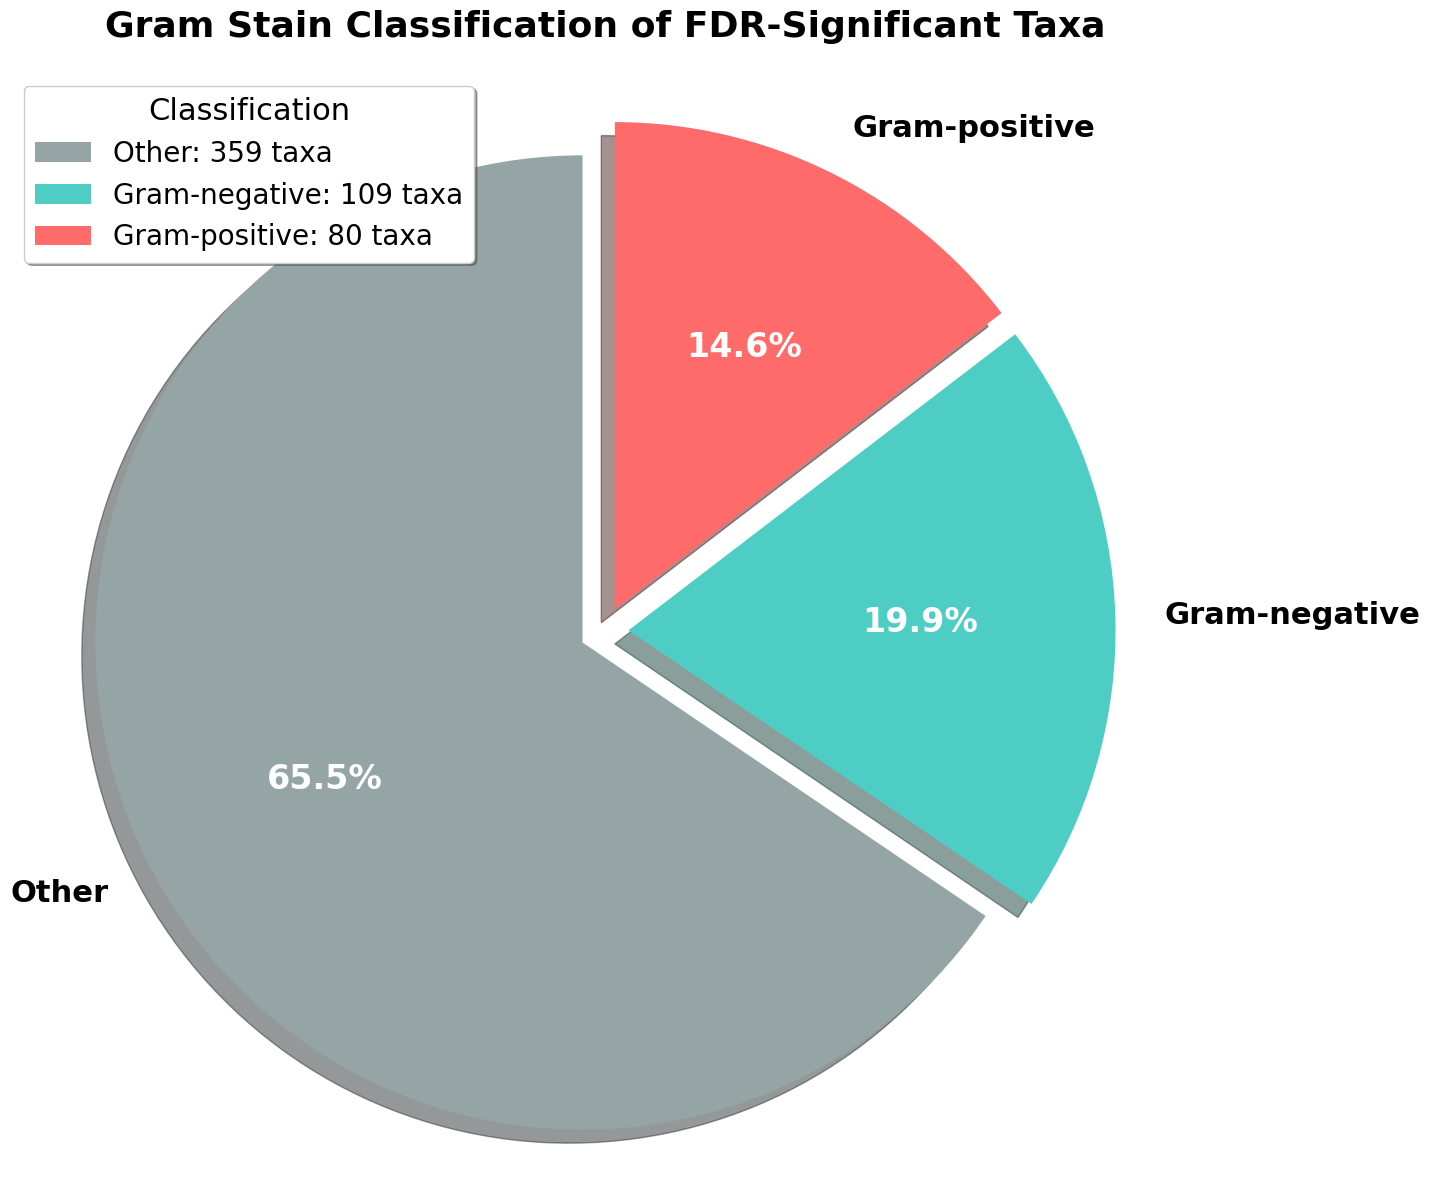


Detailed breakdown by subcategory:
  Other (Unclassified): 345 (63.0%)
  Gram-negative: 109 (19.9%)
  Gram-positive: 80 (14.6%)
  Other (Fungi): 10 (1.8%)
  Other (No cell wall): 4 (0.7%)


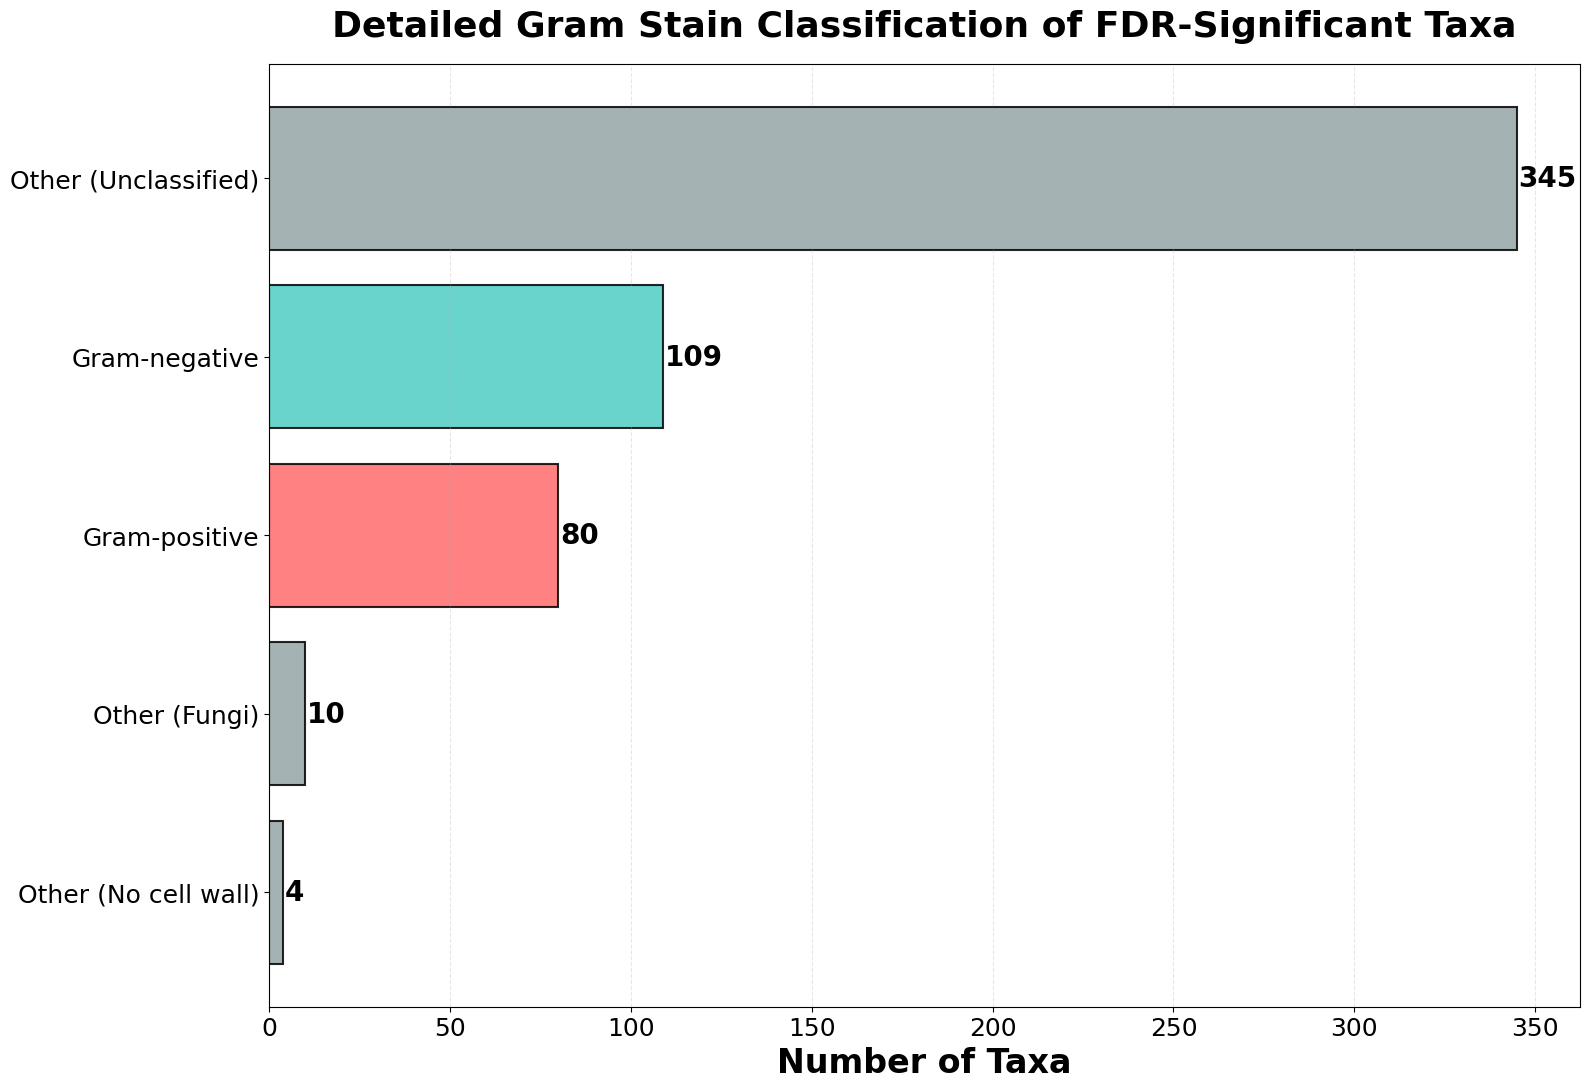


Saved files:
  - ../results/big_font_gram_stain_classification_pie.pdf
  - ../results/big_font_gram_stain_detailed_bar.pdf
  - ../results/gram_stain_classification.csv

Examples from each category:

Gram-negative:
  - Aliivibrio salmonicida+FF2:G540
  - Burkholderiales bacterium
  - Treponema pedis

Other (Unclassified):
  - Citromicrobium sp. JL47
  - Mucilaginibacter gotj
  - Methylobacterium sp. DM

Gram-positive:
  - Roseburia hominis
  - Clostridium bornimens
  - Bacillus butanolivorans

Other (Fungi):
  - Candidatus Profftella
  - Candidatus Methylopum
  - Candidatus Phaeomarin

Other (No cell wall):
  - Mycoplasma sp. 237IA
  - Mycoplasma penetrans
  - Mycoplasma canadense


In [28]:
# ---------- GRAM STAIN CLASSIFICATION OF SIGNIFICANT TAXA ----------

def classify_gram_stain(feature_name):
    """
    Classify bacteria as Gram-positive, Gram-negative, or Other based on taxonomic names.
    """
    if not isinstance(feature_name, str):
        return 'Other'
    
    name = feature_name.lower().strip()
    
    # Gram-positive bacteria (thick peptidoglycan layer)
    gram_positive_patterns = [
        # Firmicutes (mostly Gram-positive)
        'clostrid', 'bacill', 'lactobacill', 'streptococ', 'enterococ', 'staphylococ',
        'listeria', 'peptostrep', 'eubacter', 'ruminococ', 'faecalibacter',
        'roseburia', 'blautia', 'coprococ', 'dorea', 'lachnospir', 'anaerostipes',
        
        # Actinobacteria (Gram-positive)
        'actinobacter', 'bifidobacter', 'corynebacter', 'mycobacter', 'propionibacter',
        'actinomyc', 'nocardia', 'rhodococ', 'micrococ', 'arthrobacter'
    ]
    
    # Gram-negative bacteria (thin peptidoglycan layer + outer membrane)
    gram_negative_patterns = [
        # Proteobacteria (Gram-negative)
        'proteobacter', 'escherichia', 'salmonella', 'pseudomon', 'helicobacter',
        'campylobacter', 'vibrio', 'shigella', 'klebsiella', 'enterobacter',
        'citrobacter', 'serratia', 'proteus', 'yersinia', 'acinetobacter',
        'burkholder', 'stenotroph', 'xanthomon', 'ralstonia', 'alcaligen',
        
        # Bacteroidetes (Gram-negative)
        'bacteroid', 'prevotella', 'porphyromon', 'flavobacter', 'capnocytoph',
        'chryseobacter', 'elizabethking', 'weeksella',
        
        # Fusobacteria (Gram-negative)
        'fusobacter', 'leptotrichia',
        
        # Spirochaetes (Gram-negative)
        'spirochaet', 'treponema', 'borrelia', 'leptospira',
        
        # Other Gram-negative
        'neisseria', 'moraxella', 'haemophilus', 'pasteurella', 'francisella'
    ]
    
    # Check for Gram-positive patterns
    if any(pattern in name for pattern in gram_positive_patterns):
        return 'Gram-positive'
    
    # Check for Gram-negative patterns
    elif any(pattern in name for pattern in gram_negative_patterns):
        return 'Gram-negative'
    
    # Special cases and other classifications
    elif any(x in name for x in ['mycoplasma', 'tenericutes']):
        return 'Other (No cell wall)'  # Mycoplasma lack cell walls
    elif any(x in name for x in ['archaea', 'methanobrev', 'methanosph', 'halobacter']):
        return 'Other (Archaea)'
    elif any(x in name for x in ['virus', 'phage']):
        return 'Other (Virus)'
    elif any(x in name for x in ['candida', 'saccharomyc', 'cryptococ']):
        return 'Other (Fungi)'
    else:
        return 'Other (Unclassified)'

print("Classifying significant taxa by Gram stain...")

# Classify all FDR-significant taxa
gram_classifications = []
for taxon in fdr_taxa:
    classification = classify_gram_stain(taxon)
    gram_classifications.append({
        'Taxon': taxon,
        'Gram_Classification': classification
    })

# Convert to DataFrame for analysis
gram_df = pd.DataFrame(gram_classifications)

# Count classifications
gram_counts = gram_df['Gram_Classification'].value_counts()

print(f"\nGram stain classification of {len(fdr_taxa)} significant taxa:")
for classification, count in gram_counts.items():
    percentage = (count / len(fdr_taxa)) * 100
    print(f"  {classification}: {count} ({percentage:.1f}%)")

# Simplify categories for pie chart (combine "Other" subcategories)
gram_df['Simplified_Classification'] = gram_df['Gram_Classification'].apply(
    lambda x: 'Other' if x.startswith('Other') else x
)

simplified_counts = gram_df['Simplified_Classification'].value_counts()

# Create pie chart
plt.figure(figsize=(14, 12))
colors = {
    'Gram-positive': '#FF6B6B',
    'Gram-negative': '#4ECDC4',
    'Other': '#95A5A6'
}

pie_colors = [colors.get(cat, '#95A5A6') for cat in simplified_counts.index]

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    simplified_counts.values,
    labels=simplified_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    textprops={'fontsize': 22, 'fontweight': 'bold'},
    explode=[0.05] * len(simplified_counts),
    shadow=True
)

# Enhance the appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(24)

for text in texts:
    text.set_fontsize(22)
    text.set_fontweight('bold')

plt.title('Gram Stain Classification of FDR-Significant Taxa', 
          fontsize=26, fontweight='bold', pad=25)

# Add a legend with counts
legend_labels = [f'{cat}: {count} taxa' for cat, count in simplified_counts.items()]
plt.legend(wedges, legend_labels, title="Classification", 
          loc="upper left", fontsize=20, title_fontsize=22, 
          frameon=True, shadow=True, fancybox=True)

plt.axis('equal')
plt.tight_layout()
plt.savefig('../results/big_font_gram_stain_classification_pie.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Create detailed breakdown table
print("\nDetailed breakdown by subcategory:")
detailed_counts = gram_df['Gram_Classification'].value_counts()
for classification, count in detailed_counts.items():
    percentage = (count / len(fdr_taxa)) * 100
    print(f"  {classification}: {count} ({percentage:.1f}%)")

# Save the classification data
gram_df.to_csv('../results/gram_stain_classification.csv', index=False)

# Create a horizontal bar chart for detailed view
plt.figure(figsize=(16, 11))
detailed_counts_sorted = detailed_counts.sort_values(ascending=True)

# Color mapping for detailed categories
detail_colors = []
for cat in detailed_counts_sorted.index:
    if 'Gram-positive' in cat:
        detail_colors.append('#FF6B6B')
    elif 'Gram-negative' in cat:
        detail_colors.append('#4ECDC4')
    else:
        detail_colors.append('#95A5A6')

bars = plt.barh(range(len(detailed_counts_sorted)), detailed_counts_sorted.values, 
                color=detail_colors, alpha=0.85, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, detailed_counts_sorted.values)):
    plt.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2, 
             f'{value}', ha='left', va='center', fontweight='bold', fontsize=20)

plt.yticks(range(len(detailed_counts_sorted)), detailed_counts_sorted.index, fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel('Number of Taxa', fontsize=24, fontweight='bold')
plt.title('Detailed Gram Stain Classification of FDR-Significant Taxa', 
          fontsize=26, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../results/big_font_gram_stain_detailed_bar.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved files:")
print(f"  - ../results/big_font_gram_stain_classification_pie.pdf")
print(f"  - ../results/big_font_gram_stain_detailed_bar.pdf")
print(f"  - ../results/gram_stain_classification.csv")

# Show some examples of each category
print(f"\nExamples from each category:")
for classification in gram_df['Gram_Classification'].unique():
    examples = gram_df[gram_df['Gram_Classification'] == classification]['Taxon'].head(3).tolist()
    print(f"\n{classification}:")
    for example in examples:
        print(f"  - {example}")